# YouTube AI vs. Human Narration — Exploratory Notebook

Scratch space for eyeballing the pipeline outputs before running the statistical module.

Expected inputs:
- `../data/processed/cleaned_dataset.csv` (from `--preprocess`)
- `../data/processed/sentiment_dataset.csv` (from `--sentiment`)


In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

In [2]:
cleaned = pd.read_csv(ROOT / 'data' / 'processed' / 'cleaned_dataset.csv')
print('cleaned shape:', cleaned.shape)
cleaned.head(3)

cleaned shape: (39600, 21)


,video_id,comment_id,text,comment_likeCount,comment_publishedAt,author,channel_id,title,publishedAt,viewCount,likeCount,commentCount,duration_seconds,narration_type,genre,text_raw,text_clean,word_count,like_to_view_ratio,comment_rate,authenticity_flag
0,3JdpD3X2Md8,UgxpI0C1_X4xrnLjBxB4AaABAg,"Sage is such a joy, I hope yall consider her f...",59,2026-04-16T18:17:40Z,@LeebMilder,UCX6b17PVsYBQ0ip5gyeme-Q,How did Earth form?: Crash Course Geology #2,2026-04-16T16:00:04Z,18450,1461,35,572,human,science,"Sage is such a joy, I hope yall consider her f...",sage is such a joy i hope yall consider her fo...,16,0.079187,0.001897,False
1,3JdpD3X2Md8,UgzAwj9HEpE79IpqwkN4AaABAg,Sage is incredible. Pure joy to witness,38,2026-04-16T18:32:09Z,@sachinaraszkiewicz785,UCX6b17PVsYBQ0ip5gyeme-Q,How did Earth form?: Crash Course Geology #2,2026-04-16T16:00:04Z,18450,1461,35,572,human,science,Sage is incredible. Pure joy to witness,sage is incredible pure joy to witness,7,0.079187,0.001897,False
2,3JdpD3X2Md8,UgyJIv6OJQU052JuPw94AaABAg,"Rocks may rock, but Sage is super!",26,2026-04-16T16:16:41Z,@SpencerN.C.,UCX6b17PVsYBQ0ip5gyeme-Q,How did Earth form?: Crash Course Geology #2,2026-04-16T16:00:04Z,18450,1461,35,572,human,science,"Rocks may rock, but Sage is super!",rocks may rock but sage is super,7,0.079187,0.001897,False


In [3]:
cleaned['narration_type'].value_counts()

narration_type
human    22966
ai       16634
Name: count, dtype: int64

In [4]:
sentiment = pd.read_csv(ROOT / 'data' / 'processed' / 'sentiment_dataset.csv')
print('sentiment shape:', sentiment.shape)
sentiment.head(3)

sentiment shape: (631, 16)


,video_id,mean_sentiment,std_sentiment,pct_negative,pct_positive,authenticity_flag_rate,n_comments,channel_id,narration_type,genre,title,viewCount,likeCount,commentCount,like_to_view_ratio,comment_rate
0,-0JKHuzJ67A,0.514730,0.407323,0.071429,0.775510,0.000000,98,UC6107grRI4m0o2-emgoDnAA,ai,science,Everything About Disc Golf Aerodynamics - Smar...,709331,23476,2242,0.033096,0.003161
1,-2NF65wd5Tg,0.330357,0.442847,0.115789,0.610526,0.042105,95,UCb_MAhL8Thb3HJ_wPkH3gcw,ai,facts,Why so many men go to Turkey for hair transplants,151462,5486,598,0.036220,0.003948
2,-3mKkrqMi9U,0.141575,0.219873,0.000000,0.375000,0.125000,8,UC295-Dw_tDNtZXFeAPAW6Aw,ai,top-lists,🌟 SMART HOME GADGETS 🏡 Cleaning Tips & More,172136,430,30,0.002498,0.000174


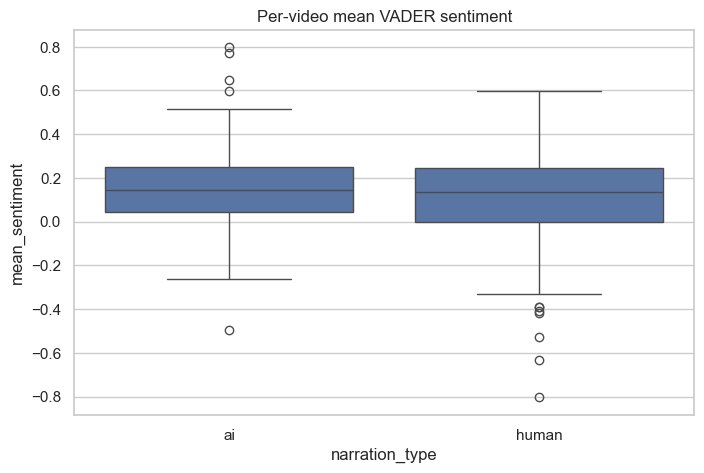

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=sentiment, x='narration_type', y='mean_sentiment', ax=ax)
ax.set_title('Per-video mean VADER sentiment')
plt.show()

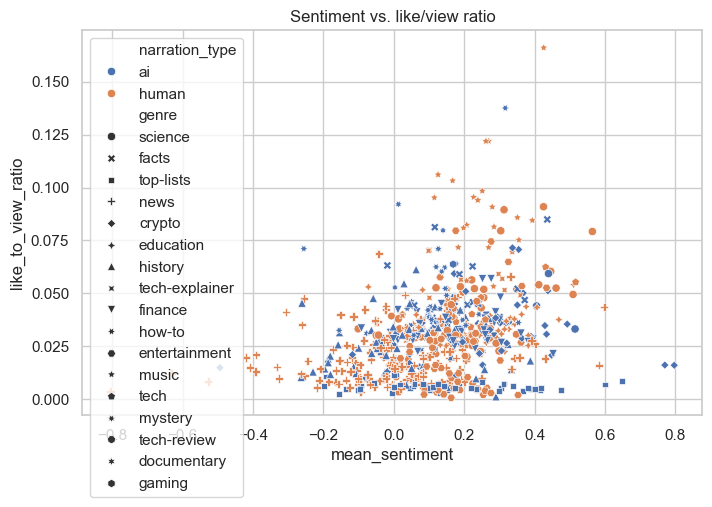

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=sentiment, x='mean_sentiment', y='like_to_view_ratio',
    hue='narration_type', style='genre', ax=ax,
)
ax.set_title('Sentiment vs. like/view ratio')
plt.show()